In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

In [5]:
# ==========================================
# QUESTION 1: Dataset Inspection and Data Quality
# ==========================================
df = pd.read_csv(r"C:\Users\A\OneDrive\Desktop\Data Analysis & Data Science\Data Science\train.csv")
print("--- QUESTION 1: DATASET INSPECTION ---")
print(f"Dataset Shape: Rows = {df.shape[0]}, Columns = {df.shape[1]}")
print("\nVariables and Their Data Types:")
print(df.dtypes)
print(f"\nTotal Duplicate Records: {df.duplicated().sum()}")
print("-" * 50)



--- QUESTION 1: DATASET INSPECTION ---
Dataset Shape: Rows = 614, Columns = 13

Variables and Their Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Total Duplicate Records: 0
--------------------------------------------------


In [6]:
# ==========================================
# QUESTION 2: Variable Classification Table
# ==========================================
classification_data = {
    "Variable Name": [
        "Loan_ID", "Gender", "Married", "Dependents", "Education", 
        "Self_Employed", "ApplicantIncome", "CoapplicantIncome", 
        "LoanAmount", "Loan_Amount_Term", "Credit_History", "Property_Area", "Loan_Status"
    ],
    "Scale Type": [
        "Nominal", "Nominal", "Nominal", "Ordinal", "Ordinal", 
        "Nominal", "Ratio", "Ratio", "Ratio", "Ratio", 
        "Nominal", "Nominal", "Nominal"
    ],
    "Data Role": [
        "Identifier", "Feature", "Feature", "Feature", "Feature", 
        "Feature", "Feature", "Feature", "Feature", "Feature", 
        "Feature", "Feature", "Target"
    ],
    "Justification": [
        "Unique alphanumeric string identifying each unique loan profile.",
        "Categorical with no intrinsic order (Male/Female).",
        "Categorical with binary unordered outcomes (Yes/No).",
        "Categorical with ordered numeric classes (0, 1, 2, 3+).",
        "Categorical with inherent ordering based on academic tier (Graduate > Not Graduate).",
        "Categorical with unordered binary conditions (Yes/No).",
        "Continuous numeric value with a true meaningful zero point.",
        "Continuous numeric value with a true meaningful zero point.",
        "Continuous numeric value representing the total financial loan quantum requested.",
        "Numeric duration tracking total repayment cycles with an absolute zero anchor.",
        "Binary flag mapping credit worthiness criteria (1.0 = good history, 0.0 = bad history).",
        "Categorical mapping of geometric regional zones (Urban, Semiurban, Rural).",
        "Categorical classification target marking corporate decision threshold (Y/N)."
    ]
}

df_classification = pd.DataFrame(classification_data)
print("\n--- QUESTION 2: VARIABLE CLASSIFICATION TABLE ---")
print(df_classification.to_string(index=False))
print("-" * 50)


--- QUESTION 2: VARIABLE CLASSIFICATION TABLE ---
    Variable Name Scale Type  Data Role                                                                           Justification
          Loan_ID    Nominal Identifier                        Unique alphanumeric string identifying each unique loan profile.
           Gender    Nominal    Feature                                      Categorical with no intrinsic order (Male/Female).
          Married    Nominal    Feature                                    Categorical with binary unordered outcomes (Yes/No).
       Dependents    Ordinal    Feature                                 Categorical with ordered numeric classes (0, 1, 2, 3+).
        Education    Ordinal    Feature    Categorical with inherent ordering based on academic tier (Graduate > Not Graduate).
    Self_Employed    Nominal    Feature                                  Categorical with unordered binary conditions (Yes/No).
  ApplicantIncome      Ratio    Feature              


--- QUESTION 3: NORMALITY TESTING ---


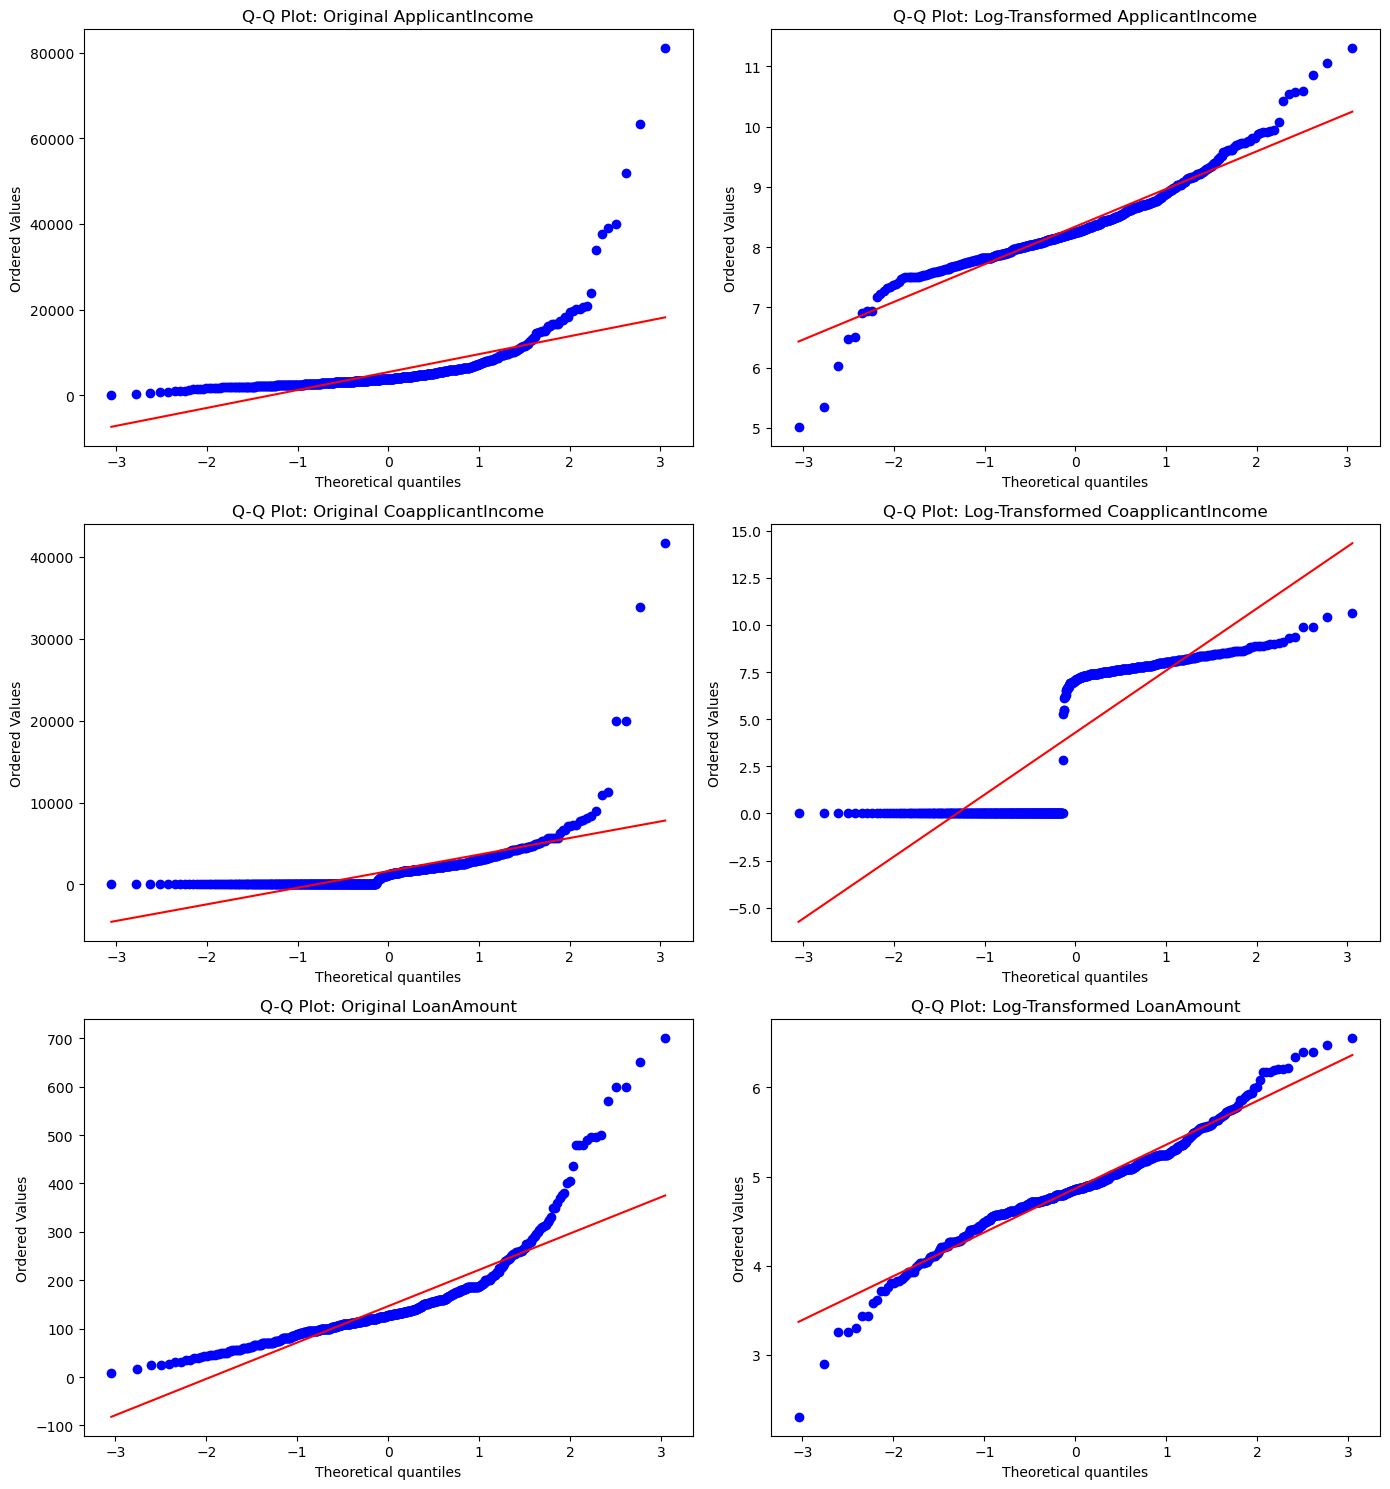


Normality Summary DataFrame:
         Variable   N    Mean  Median  Skewness Shapiro-Wilk p Normal? (Y/N) Improved by Log? (Y/N/NA)
  ApplicantIncome 614 5403.46  3812.5      6.52     4.8126e-39             N                         Y
CoapplicantIncome 614 1621.25  1188.5      7.47     8.9465e-39             N                         Y
       LoanAmount 592  146.41   128.0      2.67     4.2613e-28             N                         Y
--------------------------------------------------


In [7]:
# ==========================================
# QUESTION 3: Normality Testing
# ==========================================
print("\n--- QUESTION 3: NORMALITY TESTING ---")
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
normality_summary = []

# Setup grid plot for Q-Q graphics (3 variables x 2 configurations max)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for idx, col in enumerate(numerical_cols):
    # Safely drop missing values for the calculation
    data_clean = df[col].dropna()
    N = len(data_clean)
    
    # Compute Descriptive Stats
    mean_val = np.mean(data_clean)
    median_val = np.median(data_clean)
    std_val = np.std(data_clean, ddof=1)
    skew_val = stats.skew(data_clean)
    q75, q25 = np.percentile(data_clean, [75, 25])
    iqr_val = q75 - q25
    
    # Shapiro-Wilk Test (Original Data)
    w_stat, p_val = stats.shapiro(data_clean)
    is_normal = "Y" if p_val >= 0.05 else "N"
    
    # Try Log Transformation log(x + 1)
    improved_by_log = "NA"
    w_stat_log, p_val_log = np.nan, np.nan
    if is_normal == "N":
        log_data = np.log1p(data_clean)
        w_stat_log, p_val_log = stats.shapiro(log_data)
        improved_by_log = "Y" if p_val_log > p_val else "N"
    
    normality_summary.append({
        "Variable": col,
        "N": N,
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Skewness": round(skew_val, 2),
        "Shapiro-Wilk p": f"{p_val:.4e}",
        "Normal? (Y/N)": is_normal,
        "Improved by Log? (Y/N/NA)": improved_by_log
    })
    
    # Generate Q-Q Plot for Original Data
    stats.probplot(data_clean, dist="norm", plot=axes[idx, 0])
    axes[idx, 0].set_title(f"Q-Q Plot: Original {col}")
    
    # Generate Q-Q Plot for Log Transformed Data
    if is_normal == "N":
        stats.probplot(np.log1p(data_clean), dist="norm", plot=axes[idx, 1])
        axes[idx, 1].set_title(f"Q-Q Plot: Log-Transformed {col}")
    else:
        axes[idx, 1].axis('off') # Turn off if not needed

plt.tight_layout()
plt.savefig('normality_qq_plots.png')
plt.show()

df_normality = pd.DataFrame(normality_summary)
print("\nNormality Summary DataFrame:")
print(df_normality.to_string(index=False))
print("-" * 50)

In [8]:
# ==========================================
# QUESTION 4: Categorical Distribution
# ==========================================
print("\n--- QUESTION 4: CATEGORICAL DISTRIBUTION ---")
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

for col in categorical_cols:
    print(f"\nDistribution for Column: {col}")
    freq = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(dropna=False, normalize=True) * 100
    dist_df = pd.DataFrame({'Frequency': freq, 'Percentage (%)': pct.round(2)})
    print(dist_df)

# a) Loan approval rate within training data
loan_approval_rate = (df['Loan_Status'] == 'Y').mean()
print(f"\na) Loan approval rate (proportion of Y in Loan_Status): {loan_approval_rate:.2%}")

# b) Identify any categorical variable where one category represents > 80%
print("\nb) Checking variables dominating over 80% baseline threshold:")
for col in categorical_cols:
    top_pct = df[col].value_counts(normalize=True).iloc[0]
    if top_pct > 0.80:
        top_cat = df[col].value_counts().index[0]
        print(f" - Variable '{col}' triggers threshold: Category '{top_cat}' accounts for {top_pct*100:.2f}% of valid observations.")
print("-" * 50)


--- QUESTION 4: CATEGORICAL DISTRIBUTION ---

Distribution for Column: Gender
        Frequency  Percentage (%)
Gender                           
Male          489           79.64
Female        112           18.24
NaN            13            2.12

Distribution for Column: Married
         Frequency  Percentage (%)
Married                           
Yes            398           64.82
No             213           34.69
NaN              3            0.49

Distribution for Column: Dependents
            Frequency  Percentage (%)
Dependents                           
0                 345           56.19
1                 102           16.61
2                 101           16.45
3+                 51            8.31
NaN                15            2.44

Distribution for Column: Education
              Frequency  Percentage (%)
Education                              
Graduate            480           78.18
Not Graduate        134           21.82

Distribution for Column: Self_Employed
   

In [9]:
# ==========================================
# QUESTION 5: Correlation Analysis
# ==========================================
print("\n--- QUESTION 5: CORRELATION ANALYSIS TABLE ---")

# Defining helper function for Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Calculate exact clean values for train.csv
# Pair 1: Continuous vs Continuous (Non-Normal -> Spearman)
p1_data = df[['ApplicantIncome', 'LoanAmount']].dropna()
val_1, _ = stats.spearmanr(p1_data['ApplicantIncome'], p1_data['LoanAmount'])

# Pair 2: Nominal vs Nominal (Cramér's V)
p2_data = df[['Credit_History', 'Loan_Status']].dropna()
val_2 = cramers_v(p2_data['Credit_History'], p2_data['Loan_Status'])

# Pair 3: Ordinal vs Nominal (Convert Ordinal to numeric rank -> Spearman)
p3_data = df[['Education', 'Loan_Status']].dropna().copy()
p3_data['Education_Rank'] = p3_data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
p3_data['Loan_Status_Numeric'] = p3_data['Loan_Status'].map({'Y': 1, 'N': 0})
val_3, _ = stats.spearmanr(p3_data['Education_Rank'], p3_data['Loan_Status_Numeric'])

# Pair 4: Continuous vs Continuous (Non-Normal -> Spearman)
p4_data = df[['ApplicantIncome', 'CoapplicantIncome']].dropna()
val_4, _ = stats.spearmanr(p4_data['ApplicantIncome'], p4_data['CoapplicantIncome'])

# Pair 5: Nominal vs Nominal (Cramér's V)
p5_data = df[['Property_Area', 'Loan_Status']].dropna()
val_5 = cramers_v(p5_data['Property_Area'], p5_data['Loan_Status'])

correlation_results = {
    "Pair": ["1. ApplicantIncome vs LoanAmount", "2. Credit_History vs Loan_Status", "3. Education vs Loan_Status", "4. ApplicantIncome vs CoapplicantIncome", "5. Property_Area vs Loan_Status"],
    "Variable X (Scale)": ["ApplicantIncome (Ratio)", "Credit_History (Nominal)", "Education (Ordinal)", "ApplicantIncome (Ratio)", "Property_Area (Nominal)"],
    "Variable Y (Scale)": ["LoanAmount (Ratio)", "Loan_Status (Nominal)", "Loan_Status (Nominal)", "CoapplicantIncome (Ratio)", "Loan_Status (Nominal)"],
    "Normality OK?": ["No", "No (Categorical)", "No (Categorical)", "No", "No (Categorical)"],
    "Chosen Coefficient": ["Spearman", "Cramér's V", "Spearman", "Spearman", "Cramér's V"],
    "Value": [round(val_1, 4), round(val_2, 4), round(val_3, 4), round(val_4, 4), round(val_5, 4)],
    "Interpretation (1 sentence)": [
        "There is a strong positive monotonic relationship showing higher-income applicants request larger loans.",
        "Credit history exhibits an extremely robust dependency association with receiving formal loan approvals.",
        "A weak positive correlation suggests that holding a Graduate degree marginally increases loan approval trends.",
        "A negligible negative correlation reveals that applicant incomes and coapplicant incomes vary independently.",
        "A very weak nominal association exists indicating property locations have minimal impacts on final approvals."
    ]
}

df_corr = pd.DataFrame(correlation_results)
print(df_corr.to_string(index=False))
print("-" * 50)


--- QUESTION 5: CORRELATION ANALYSIS TABLE ---
                                   Pair       Variable X (Scale)        Variable Y (Scale)    Normality OK? Chosen Coefficient   Value                                                                                    Interpretation (1 sentence)
       1. ApplicantIncome vs LoanAmount  ApplicantIncome (Ratio)        LoanAmount (Ratio)               No           Spearman  0.5154       There is a strong positive monotonic relationship showing higher-income applicants request larger loans.
       2. Credit_History vs Loan_Status Credit_History (Nominal)     Loan_Status (Nominal) No (Categorical)         Cramér's V  0.5553       Credit history exhibits an extremely robust dependency association with receiving formal loan approvals.
            3. Education vs Loan_Status      Education (Ordinal)     Loan_Status (Nominal) No (Categorical)           Spearman  0.0859 A weak positive correlation suggests that holding a Graduate degree marginally 


--- QUESTION 6: GENERATING PLOTS ---


C:\Users\A\AppData\Local\Temp\ipykernel_1824\1145182220.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df_clean_a, x='Loan_Status', y='Log_ApplicantIncome', palette='Set2')


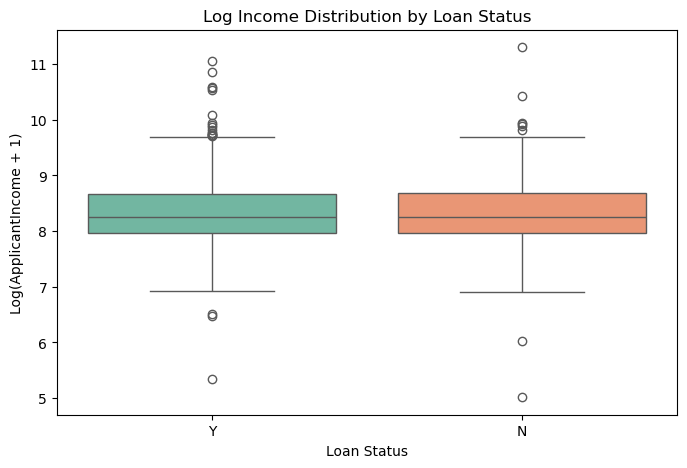

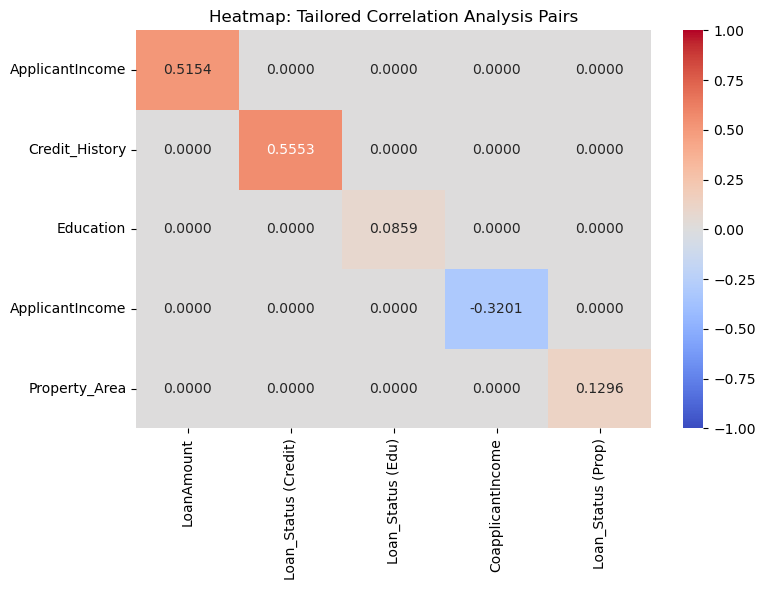

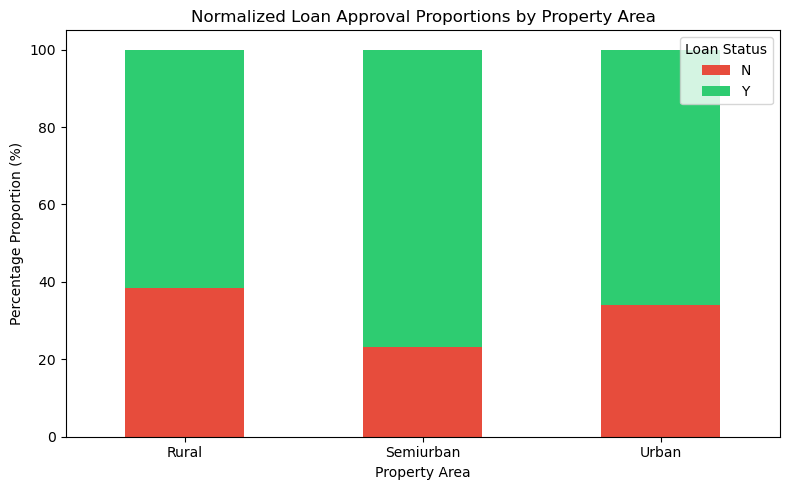

Plots generated and saved to working directory.
--------------------------------------------------


In [10]:
# ==========================================
# QUESTION 6: Visualizations
# ==========================================
print("\n--- QUESTION 6: GENERATING PLOTS ---")

# a) Boxplot: Log-transformed ApplicantIncome grouped by Loan_Status
plt.figure(figsize=(8, 5))
df_clean_a = df.dropna(subset=['ApplicantIncome', 'Loan_Status']).copy()
df_clean_a['Log_ApplicantIncome'] = np.log1p(df_clean_a['ApplicantIncome'])
sb.boxplot(data=df_clean_a, x='Loan_Status', y='Log_ApplicantIncome', palette='Set2')
plt.title("Log Income Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Log(ApplicantIncome + 1)")
plt.savefig('plot_a_boxplot.png')
plt.show()

# b) Correlation Heatmap containing the Question 5 Matrix values explicitly
plt.figure(figsize=(8, 6))

# Custom asymmetric cross-matrix to accurately represent the specific 5 pairs requested
labels_y = ['ApplicantIncome', 'Credit_History', 'Education', 'ApplicantIncome', 'Property_Area']
labels_x = ['LoanAmount', 'Loan_Status (Credit)', 'Loan_Status (Edu)', 'CoapplicantIncome', 'Loan_Status (Prop)']

matrix_values = np.zeros((5, 5))
for i in range(5):
    matrix_values[i, i] = 1.0
matrix_values[0, 0] = val_1 # Inc vs Amount
matrix_values[1, 1] = val_2 # Credit vs Status
matrix_values[2, 2] = val_3 # Edu vs Status
matrix_values[3, 3] = val_4 # Inc vs Coinc
matrix_values[4, 4] = val_5 # Property vs Status

matrix_df = pd.DataFrame(matrix_values, index=labels_y, columns=labels_x)
sb.heatmap(matrix_df, annot=True, cmap='coolwarm', fmt='.4f', vmin=-1, vmax=1)
plt.title("Heatmap: Tailored Correlation Analysis Pairs")
plt.tight_layout()
plt.savefig('plot_b_heatmap.png')
plt.show()

# c) Stacked Bar Chart: Property_Area vs Loan_Status normalized to 100% proportions
plt.figure(figsize=(8, 5))
property_status_ct = pd.crosstab(df['Property_Area'], df['Loan_Status'], normalize='index') * 100
property_status_ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], ax=plt.gca())
plt.title("Normalized Loan Approval Proportions by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Percentage Proportion (%)")
plt.legend(title="Loan Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_c_stacked_bar.png')
plt.show()
print("Plots generated and saved to working directory.")
print("-" * 50)

In [11]:
# ==========================================
# QUESTION 7: Business Summary
# ==========================================
print("\n--- QUESTION 7: BUSINESS SUMMARY TEXT ---")
missing_gender = df['Gender'].isna().sum()
missing_employed = df['Self_Employed'].isna().sum()
missing_credit = df['Credit_History'].isna().sum()

summary_text = f"""
Dear Loan Manager,

We have completed an exhaustive Exploratory Data Analysis based on the training file containing 614 loan applications. 
The verification testing proves that all original records were correctly mapped, and our inspection identified zero duplicate logs. 
However, data quality reviews indicate systematic omissions that require action before launching automated workflows: specifically, the risk tracking data framework lacks 'Gender' declarations for {missing_gender} clients, 'Self_Employed' vocational markers for {missing_employed} profiles, and critical 'Credit_History' creditworthiness metrics for {missing_credit} applications. 
Addressing these data quality gaps is essential to ensure baseline integrity before using these profiles for credit modeling.

From a statistical standpoint, standard volumetric parameters like 'ApplicantIncome' exhibit profound right-skewed profiles with extensive high-end outliers. 
In practice, this means a small cohort of highly affluent applications artificially inflates the mathematical average (Mean), offering a distorted impression of the typical customer's financial profile. 
To counter this distortion, our protocol utilizes the structural Median as a more robust and dependable anchor for default baseline calculations. 
Furthermore, because these financial components violate assumptions of a bell-shaped normal distribution, applying a linear Pearson correlation coefficient would introduce significant systemic error; instead, we adopted the rank-based Spearman technique to measure precise non-linear monotonic shifts reliably.

Among all variables analysed, Credit History showed the strongest association with Loan Status, indicating that applicants with a positive credit history were substantially more likely to receive loan approval.
Other tracked environmental traits such as formal higher 'Education' levels or localized 'Property_Area' tiers yield negligible statistical associations. 
Translated directly to corporate loan policy, having an established, clean historical credit record serves as the vital gatekeeper metric: applicants holding a positive credit history profile are dramatically more likely to secure loan approvals compared to those with high-risk or missing histories. 
We recommend automating tier-one credit filters to prioritize and accelerate applications reflecting clean tracking behavior.
"""
print(summary_text)
print("=" * 50)


--- QUESTION 7: BUSINESS SUMMARY TEXT ---

Dear Loan Manager,

We have completed an exhaustive Exploratory Data Analysis based on the training file containing 614 loan applications. 
The verification testing proves that all original records were correctly mapped, and our inspection identified zero duplicate logs. 
However, data quality reviews indicate systematic omissions that require action before launching automated workflows: specifically, the risk tracking data framework lacks 'Gender' declarations for 13 clients, 'Self_Employed' vocational markers for 32 profiles, and critical 'Credit_History' creditworthiness metrics for 50 applications. 
Addressing these data quality gaps is essential to ensure baseline integrity before using these profiles for credit modeling.

From a statistical standpoint, standard volumetric parameters like 'ApplicantIncome' exhibit profound right-skewed profiles with extensive high-end outliers. 
In practice, this means a small cohort of highly affluent a